In [1]:
import pandas, numpy, scipy

In [2]:
import sklearn, sklearn.preprocessing, sklearn.decomposition

In [3]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })

# 0. user-defined variables

In [4]:
input_file = '/Users/adrian/research/bmcbf/061_drangajokull/profiles/DESeq2_TPM_values.tsv'

# 1. read expression

In [5]:
expression = pandas.read_csv(input_file, sep='\t', index_col=0)
print(expression.shape)
expression

(39546, 24)


,C_1_8_siA1,C_1_8_siA2,C_1_8_siA3,C_1_8_siC1,C_1_8_siC2,C_1_8_siC3,C_4_2_siA1,C_4_2_siA2,C_4_2_siA3,C_4_2_siC1,...,C_Ctrl_siA3,C_Ctrl_siC1,C_Ctrl_siC2,C_Ctrl_siC3,P_siA1,P_siA2,P_siA3,P_siC1,P_siC2,P_siC3
ENSG00000000003.15,17.431846,14.779254,15.776189,17.942081,16.086844,19.370644,18.362094,18.312481,17.876016,17.264718,...,20.349122,21.125159,21.782244,19.694632,22.565741,22.547579,24.020538,35.246270,31.484441,32.103491
ENSG00000000005.6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.069094,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000000419.14,262.268938,241.197012,268.405798,254.670899,236.258486,248.906325,302.486509,281.434477,271.430222,281.039390,...,238.207843,225.100592,246.638183,203.629846,100.583829,95.257528,90.605960,98.856476,96.941897,89.312262
ENSG00000000457.14,4.884033,4.694906,5.058265,4.528155,4.802757,4.888046,4.701667,5.748546,5.537377,5.813769,...,10.406525,11.552579,10.192525,10.726972,6.526579,7.092396,7.063269,5.609304,5.738320,5.465651
ENSG00000000460.17,11.166456,11.031590,14.254324,10.878008,8.904711,11.765998,9.647534,11.630995,9.656493,11.338847,...,13.942121,18.869389,15.545217,17.233000,13.536950,16.758341,13.747286,18.045280,17.530634,17.772557
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000291297.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000291298.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000291299.1,1.254073,0.517551,0.592916,0.257651,0.540284,0.681753,0.742241,0.797785,0.460174,1.061948,...,0.949756,0.465748,1.061909,0.327268,0.314290,0.314525,1.063590,0.758387,1.667188,1.893993
ENSG00000291300.1,0.145760,0.022951,0.076830,0.052420,0.933282,0.274077,1.021251,0.524964,0.543643,0.252195,...,0.096569,0.288799,0.427191,0.748746,0.024370,0.070876,0.285723,0.080237,0.073676,0.000000


In [6]:
for element in expression.columns:
    print(element)

C_1_8_siA1
C_1_8_siA2
C_1_8_siA3
C_1_8_siC1
C_1_8_siC2
C_1_8_siC3
C_4_2_siA1
C_4_2_siA2
C_4_2_siA3
C_4_2_siC1
C_4_2_siC2
C_4_2_siC3
C_Ctrl_siA1
C_Ctrl_siA2
C_Ctrl_siA3
C_Ctrl_siC1
C_Ctrl_siC2
C_Ctrl_siC3
P_siA1
P_siA2
P_siA3
P_siC1
P_siC2
P_siC3


# 3. filter and transform

In [7]:
substantial_expression = expression[expression.max(axis=1) >= 2]
high_expression = expression[expression.max(axis=1) >= 100]

print(substantial_expression.shape)
print(high_expression.shape)

(14771, 24)
(2291, 24)


In [8]:
transpose = substantial_expression.transpose()
pca_substantial_expression = numpy.log2(transpose + 1)

transpose = high_expression.transpose()
pca_high_expression = numpy.log2(transpose + 1)

# 4. visualize substantial expression

In [9]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_substantial_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.53087575 0.12824361]


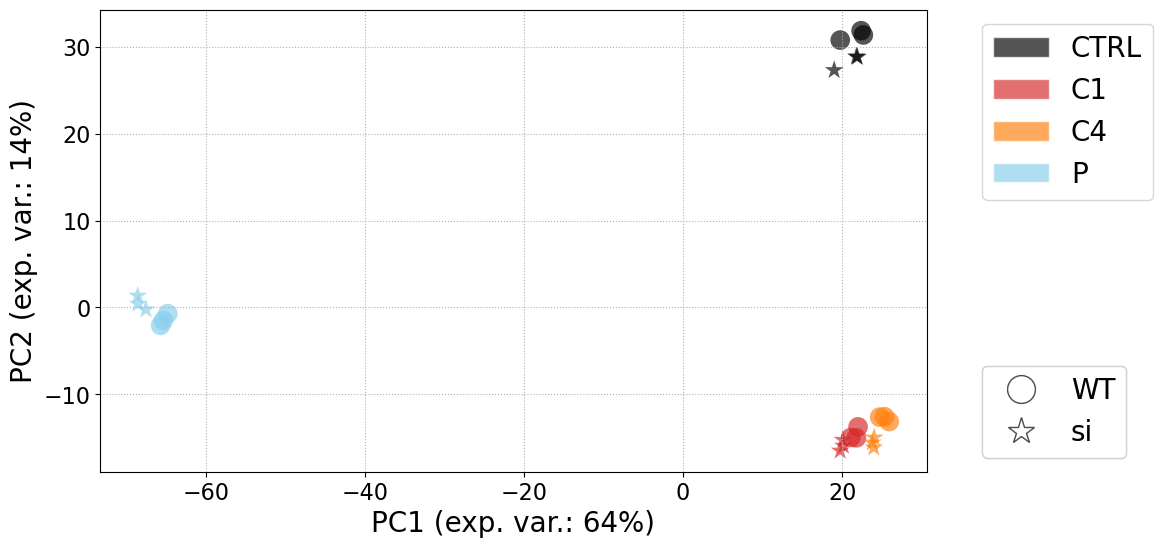

In [32]:
for i in range(len(new)):

    name = expression.columns[i]

    # colors
    if 'P_' in name:
        the_color = 'skyblue'
    elif 'C_Ctrl' in name:
        the_color = 'black'
    elif 'C_1' in name:
        the_color = 'tab:red'
    elif 'C_4' in name:
        the_color = 'tab:orange'
    else:
        print('error')

    # marker
    if 'A' in name:
        the_marker = '*'
    else:
        the_marker = 'o'
        
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=200, c=the_color, marker=the_marker, alpha=2/3, edgecolors='none')
    #epsilon = 0
    #matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, name, size=8, va='center', ha='center')


legend_elements = [
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='black',      edgecolor='white', alpha=2/3),
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:red',    edgecolor='white', alpha=2/3),
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:orange', edgecolor='white', alpha=2/3),
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='skyblue',    edgecolor='white', alpha=2/3),
]


matplotlib.pyplot.legend(legend_elements, ['CTRL', 'C1', 'C4', 'P'], ncol=1, loc='upper left', bbox_to_anchor=(1.05, 1))

# Get the current Axes
ax = matplotlib.pyplot.gca()

# Preserve the first legend
first_legend = ax.get_legend()
ax.add_artist(first_legend)

# Second legend
legend_elements_2 = [
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='white', markeredgecolor='black', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='*', markerfacecolor='white', markeredgecolor='black', markersize=20, alpha=2/3),
]

second_legend = matplotlib.pyplot.legend(
    legend_elements_2,
    ['WT', 'si'],
    ncol=1,
    loc='lower left',
    bbox_to_anchor=(1.05, 0)
)

ax.add_artist(second_legend)

    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.show()
#matplotlib.pyplot.savefig('pca.svg')

# 4. visualize high expression

In [11]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_high_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.64927705 0.14504193]


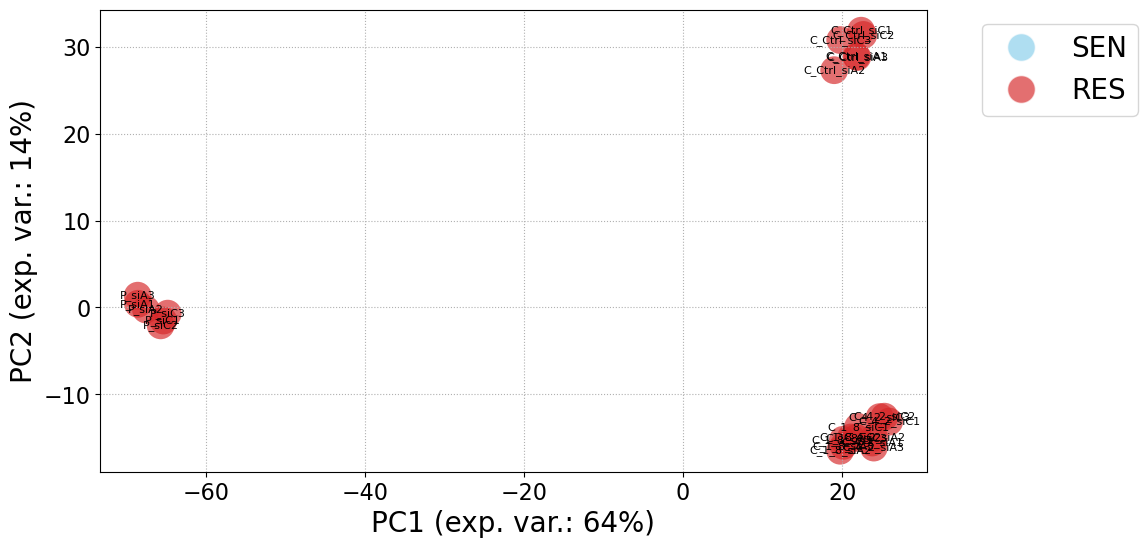

In [12]:
for i in range(len(new)):

    # colors
    name = expression.columns[i]
    
    if 'WM' in name:
        the_color = 'skyblue'
    else:
        the_color = 'tab:red'
    
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=400, c=the_color, marker='o', alpha=2/3, edgecolors='none')
    epsilon = 0
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, name, size=8, va='center', ha='center')

legend_elements = [
    
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='skyblue', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='tab:red', markeredgecolor='white', markersize=20, alpha=2/3),
    
]

matplotlib.pyplot.legend(legend_elements, ['SEN', 'RES'], ncol=1, loc='upper left', bbox_to_anchor=(1.05, 1))
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.show()
#matplotlib.pyplot.savefig('pca.svg')

In [13]:
# 5. distributions

In [14]:
log2_tpm_PO = numpy.log2(expression + 1)
log2_tpm_PO.head()

,C_1_8_siA1,C_1_8_siA2,C_1_8_siA3,C_1_8_siC1,C_1_8_siC2,C_1_8_siC3,C_4_2_siA1,C_4_2_siA2,C_4_2_siA3,C_4_2_siC1,...,C_Ctrl_siA3,C_Ctrl_siC1,C_Ctrl_siC2,C_Ctrl_siC3,P_siA1,P_siA2,P_siA3,P_siC1,P_siC2,P_siC3
ENSG00000000003.15,4.204129,3.979957,4.068343,4.243523,4.094814,4.348420,4.275163,4.271462,4.238482,4.190988,...,4.416105,4.467616,4.509838,4.371185,4.558619,4.557507,4.645041,5.179761,5.021677,5.048911
ENSG00000000005.6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.096389,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000000419.14,8.040394,7.920037,8.073637,7.998144,7.890316,7.965244,8.245489,8.141772,8.089743,8.139753,...,7.902121,7.820821,7.952090,7.676873,6.666527,6.588827,6.517370,6.641784,6.613854,6.496850
ENSG00000000457.14,2.556805,2.509672,2.598905,2.466798,2.536738,2.557789,2.511384,2.754577,2.708712,2.768453,...,3.511787,3.649912,3.484464,3.551759,2.911994,3.016567,3.011365,2.724498,2.752389,2.692796
ENSG00000000460.17,3.604837,3.588755,3.931146,3.570221,3.308115,3.674234,3.412447,3.658896,3.413661,3.625136,...,3.901313,4.312476,4.048342,4.188480,3.861653,4.150425,3.882378,4.251362,4.211840,4.230553


145
14.456975578593855


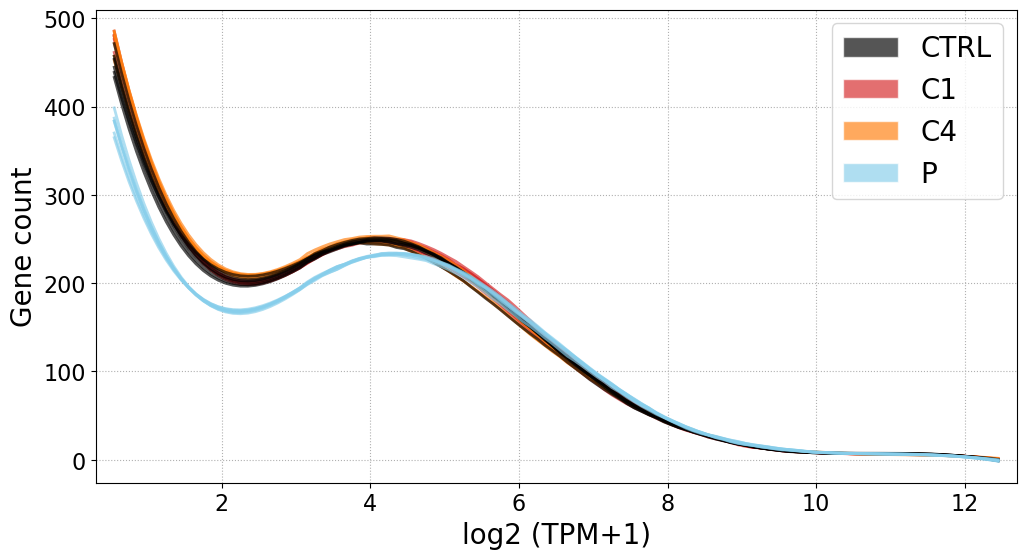

In [39]:
found_max = 14.5
number_of_bins = int(found_max*10)
print(number_of_bins)

absolute_max = 0
working_samples = log2_tpm_PO.columns.to_list()

most_likely_expressions = []
all_hats = []
for i in range(len(working_samples)):

    name = working_samples[i]

    # colors
    if 'P_' in name:
        the_color = 'skyblue'
    elif 'C_Ctrl' in name:
        the_color = 'black'
    elif 'C_1' in name:
        the_color = 'tab:red'
    elif 'C_4' in name:
        the_color = 'tab:orange'
    else:
        print('error')
    
    log2TPM = log2_tpm_PO.loc[:, name]
    if max(log2TPM) > absolute_max:
        absolute_max = max(log2TPM)
                
    hist, bin_edges = numpy.histogram(log2TPM, bins=number_of_bins, range=(0, found_max))
    half_bin = (bin_edges[1] - bin_edges[0])/2
    x = bin_edges + half_bin
    x = x[:-1]
  
    plotting_x = x[5:-20]
    plotting_hist = hist[5:-20]
    #print(plotting_x)
    
    #matplotlib.pyplot.plot(plotting_x, plotting_hist, 'o', alpha=1/5, mec='none', color=the_color)
    yhat = scipy.signal.savgol_filter(plotting_hist, 51, 3)

    matplotlib.pyplot.plot(plotting_x, yhat, '-', lw=2, alpha=2/3, color=the_color)
    
matplotlib.pyplot.xlim([numpy.min(plotting_x)-0.25, numpy.max(plotting_x)+0.25])
#matplotlib.pyplot.ylim([0, 400])

legend_elements = [
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='black',      edgecolor='white', alpha=2/3),
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:red',    edgecolor='white', alpha=2/3),
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:orange', edgecolor='white', alpha=2/3),
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='skyblue',    edgecolor='white', alpha=2/3),
]


matplotlib.pyplot.legend(legend_elements, ['CTRL', 'C1', 'C4', 'P'], ncol=1, loc='upper right')

matplotlib.pyplot.xlabel('log2 (TPM+1)')
matplotlib.pyplot.ylabel('Gene count')
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.tight_layout()

print(absolute_max)